In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import signal




In [3]:
# This notebook is to help start exploring fisheye lenses for the detection of S2 pulses in liquid xenon detectors.
# I just want to make some plots to help understand the distortion from the lens and how it affects the separation of signals from different locations

# First, I want to explore the stereographic projection, which is a common type of fisheye lens. The formula for the projection is:
# r = 2 * f * tan(theta / 2)
# where r is the distance from the center of the image, f is the focal length of
# the lens, and theta is the angle of incidence of the light ray.

In [10]:
# My sensor of choice, for now, is this one: https://www.photonfocus.com/products/uv-cmos-camera-mv4-d1280u-h01-gt-with-global-shutter/
# It features 1280 x 1024 pixels with a pixel size of 7.4x7.4 um. I need a field of view of 

pixel_size_cm = 7.4e-6 * 1e2 # m
pixels_x = 1280
pixels_y = 1024
array_size_x = pixel_size_cm * pixels_x
array_size_y = pixel_size_cm * pixels_y


print(f"Array size: {array_size_x*10:.2f} mm x {array_size_y*10:.2f} mm")

# I am imaging a flat plane and trying to discriminate between two points.
distance_to_image_cm = 10. # cm
field_of_view_radius_cm = 30. # cm

field_of_view_theta = np.arctan(field_of_view_radius_cm / distance_to_image_cm)
print(f"Field of view angle: {field_of_view_theta*180/np.pi:.2f} degrees")

print("Equidistant projection:")
# Let's start with teh equidistant projection, which is a simple fisheye lens model. The formula for the projection is:
# r = f * theta
focal_length_requirement_equidistant = array_size_y / 2 / field_of_view_theta
print(f"\tFocal length requirement for equidistant projection: {focal_length_requirement_equidistant*10:.2f} mm")

print('Stereographic projection:')
# For the stereographic projection, the formula is:
# r = 2 * f * tan(theta / 2)
focal_length_requirement_stereographic = array_size_y / 2 / (2 * np.tan(field_of_view_theta / 2))
print(f"\tFocal length requirement for stereographic projection: {focal_length_requirement_stereographic*10:.2f} mm")


print('Equisolid angle projection:')
# For the equisolid angle projection, the formula is:
# r = 2 * f * sin(theta / 2)
focal_length_requirement_equisolid = array_size_y / 2 / (2 * np.sin(field_of_view_theta / 2))
print(f"\tFocal length requirement for equisolid angle projection: {focal_length_requirement_equisolid*10:.2f} mm")

print('Orthographic projection:')
# For the orthographic projection, the formula is:
# r = f * sin(theta)
focal_length_requirement_orthographic = array_size_y / 2 / np.sin(field_of_view_theta)
print(f"\tFocal length requirement for orthographic projection: {focal_length_requirement_orthographic*10:.2f} mm")




Array size: 9.47 mm x 7.58 mm
Field of view angle: 71.57 degrees
Equidistant projection:
	Focal length requirement for equidistant projection: 3.03 mm
Stereographic projection:
	Focal length requirement for stereographic projection: 2.63 mm
Equisolid angle projection:
	Focal length requirement for equisolid angle projection: 3.24 mm
Orthographic projection:
	Focal length requirement for orthographic projection: 3.99 mm


Point spacing in object plane: 0.50 cm


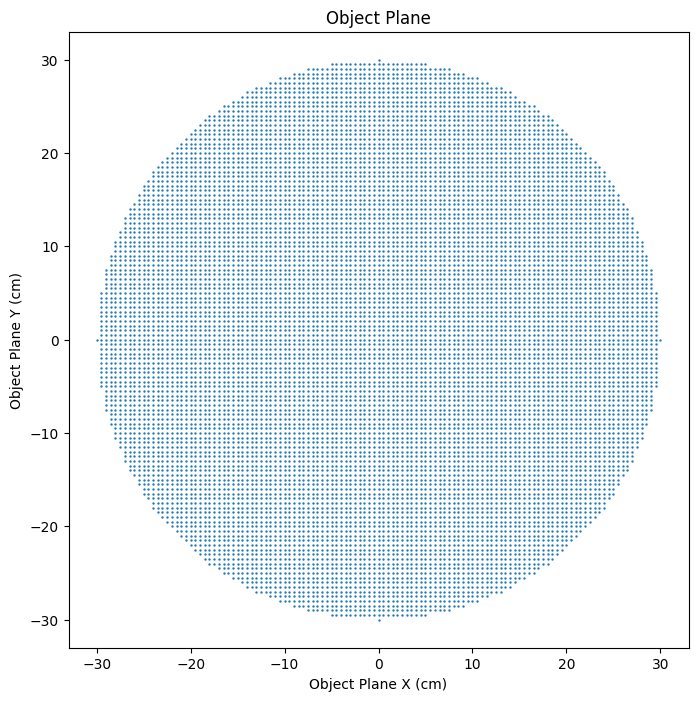

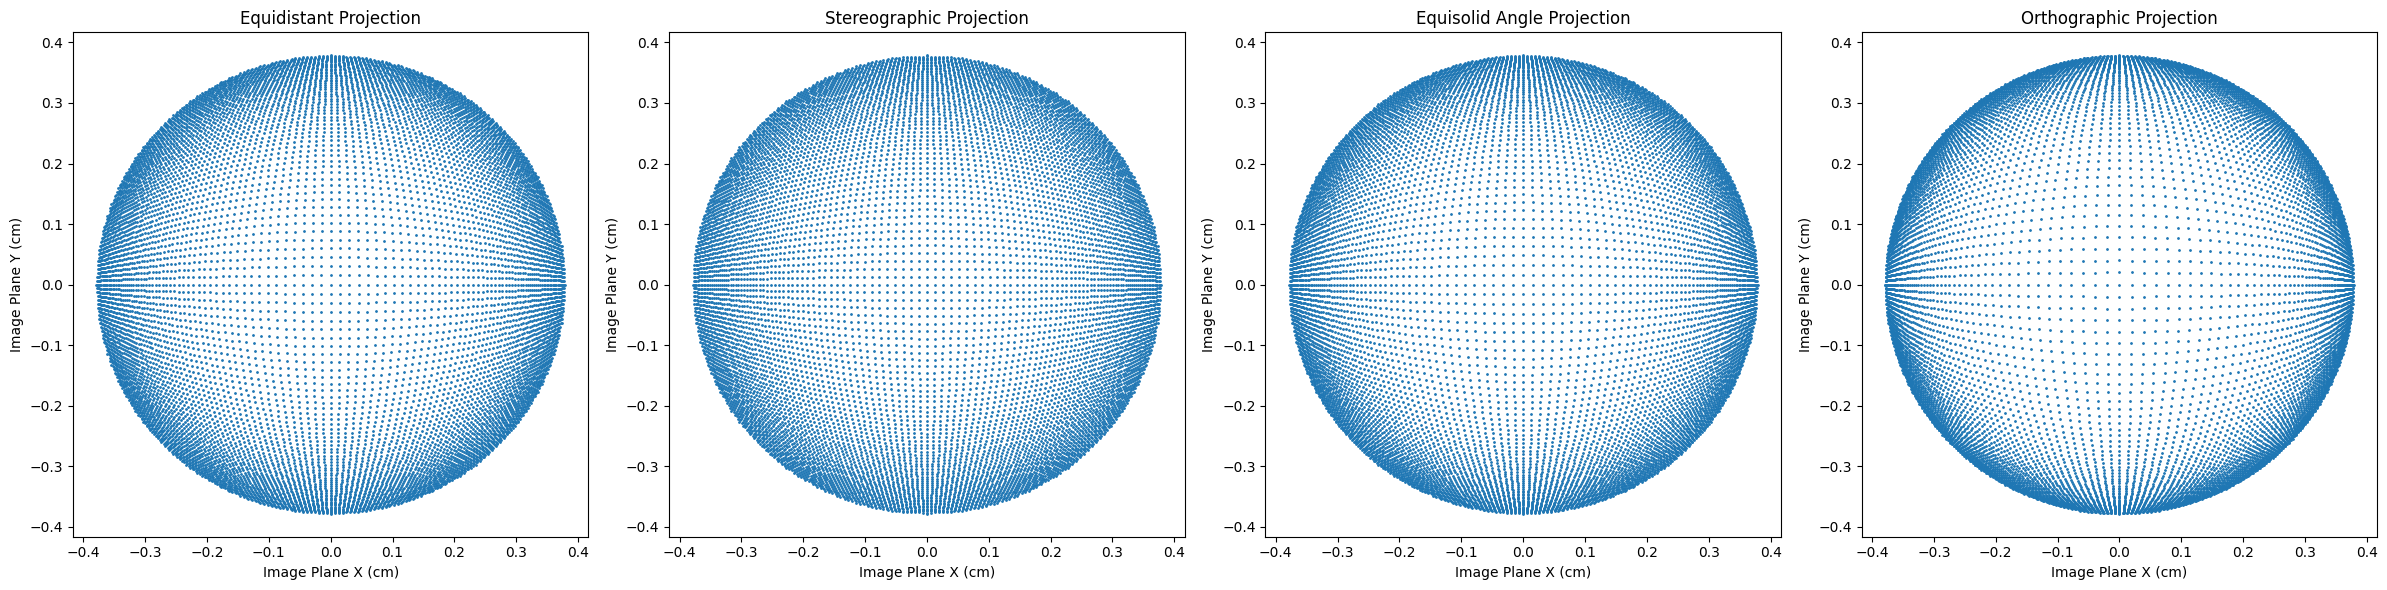

In [11]:
# Okay, let's imagine we can hit those focal lengths. What does the distortion look like? Let's plot the distortion for both projections.
# I want to plot a grid of points in the object plane and see how they are projected onto the image plane. I'll use a grid of points that covers the field of view. I want that grid to be spaced by 3mm
point_spacing_cm = 0.5 # cm
object_plane_x = np.arange(-field_of_view_radius_cm, field_of_view_radius_cm + point_spacing_cm, point_spacing_cm)
object_plane_y = np.arange(-field_of_view_radius_cm, field_of_view_radius_cm + point_spacing_cm, point_spacing_cm)

# object_plane_x = np.linspace(-field_of_view_radius_cm, field_of_view_radius_cm, 100)
# object_plane_y = np.linspace(-field_of_view_radius_cm, field_of_view_radius_cm, 100)

print('Point spacing in object plane: {:.2f} cm'.format(object_plane_x[1] - object_plane_x[0]))

# Create a meshgrid of points in the object plane
object_plane_X, object_plane_Y = np.meshgrid(object_plane_x, object_plane_y)
# Mask off a circular region outside the field of view
mask = np.sqrt(object_plane_X**2 + object_plane_Y**2) <= field_of_view_radius_cm
object_plane_X = object_plane_X[mask]
object_plane_Y = object_plane_Y[mask]
object_plane_R = np.sqrt(object_plane_X**2 + object_plane_Y**2)
object_plane_theta = np.arctan(object_plane_R / distance_to_image_cm)
object_plane_phi = np.arctan2(object_plane_Y, object_plane_X)

# Print the shapes of all the above arrays to make sure they are all the same
# print(f"object_plane_X shape: {object_plane_X.shape}")
# print(f"object_plane_Y shape: {object_plane_Y.shape}")
# print(f"object_plane_R shape: {object_plane_R.shape}")
# print(f"object_plane_theta shape: {object_plane_theta.shape}")

# Let's plot the meshgrid of points in the object plane to see what it looks like.
plt.figure(figsize=(8, 8))
plt.scatter(object_plane_X, object_plane_Y, s=0.5)
plt.title('Object Plane')
plt.xlabel('Object Plane X (cm)')
plt.ylabel('Object Plane Y (cm)')


# Now we can calculate the projected points for both projections.
# For the equidistant projection:
image_plane_X_equidistant = focal_length_requirement_equidistant * object_plane_theta * np.cos(object_plane_phi)
image_plane_Y_equidistant = focal_length_requirement_equidistant * object_plane_theta * np.sin(object_plane_phi)

# For the stereographic projection:
image_plane_X_stereographic = 2 * focal_length_requirement_stereographic * np.tan(object_plane_theta / 2) * np.cos(object_plane_phi)
image_plane_Y_stereographic = 2 * focal_length_requirement_stereographic * np.tan(object_plane_theta / 2) * np.sin(object_plane_phi)

# For the equisolid angle projection:
image_plane_X_equisolid = 2 * focal_length_requirement_equisolid * np.sin(object_plane_theta / 2) * np.cos(object_plane_phi)
image_plane_Y_equisolid = 2 * focal_length_requirement_equisolid * np.sin(object_plane_theta / 2) * np.sin(object_plane_phi)   

# For the orthographic projection:
image_plane_X_orthographic = focal_length_requirement_orthographic * np.sin(object_plane_theta) * np.cos(object_plane_phi)
image_plane_Y_orthographic = focal_length_requirement_orthographic * np.sin(object_plane_theta) * np.sin(object_plane_phi)  


# Now we can plot the results.
plt.figure(figsize=(24, 6))
plt.subplot(1, 4, 1)
plt.scatter(image_plane_X_equidistant, image_plane_Y_equidistant, s=1)
plt.title('Equidistant Projection')
plt.xlabel('Image Plane X (cm)')
plt.ylabel('Image Plane Y (cm)')
plt.subplot(1, 4, 2)
plt.scatter(image_plane_X_stereographic, image_plane_Y_stereographic, s=1)
plt.title('Stereographic Projection')
plt.xlabel('Image Plane X (cm)')
plt.ylabel('Image Plane Y (cm)')
plt.subplot(1, 4, 3)
plt.scatter(image_plane_X_equisolid, image_plane_Y_equisolid, s=1)
plt.title('Equisolid Angle Projection')
plt.xlabel('Image Plane X (cm)')
plt.ylabel('Image Plane Y (cm)')
plt.subplot(1, 4, 4)
plt.scatter(image_plane_X_orthographic, image_plane_Y_orthographic, s=1)
plt.title('Orthographic Projection')
plt.xlabel('Image Plane X (cm)')
plt.ylabel('Image Plane Y (cm)')
plt.tight_layout()
plt.show()


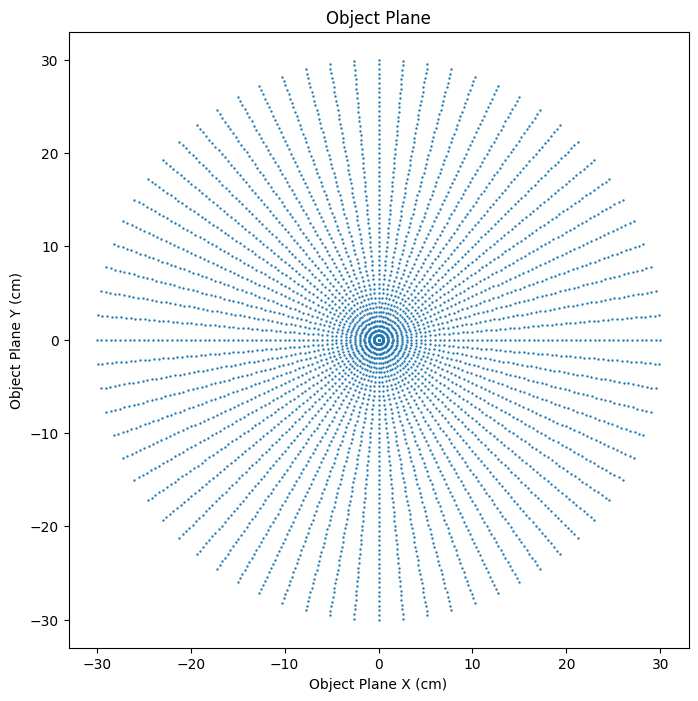

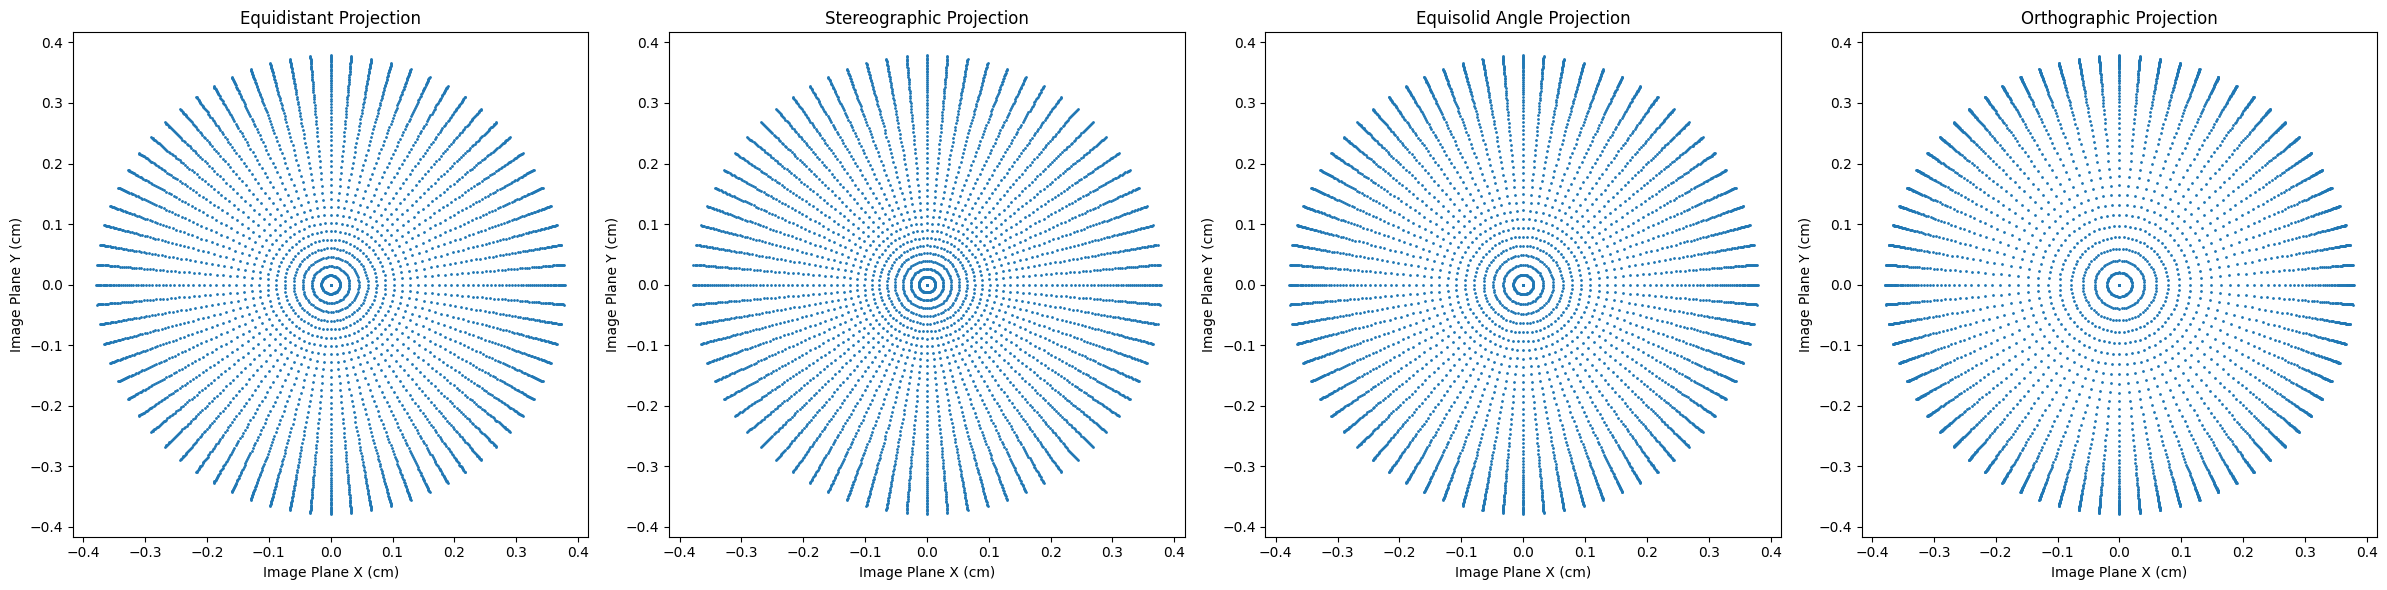

In [12]:
# Now I want to make the same plots as above, but with the grid of points on a polar grid instead of a Cartesian grid. This will help me see how the distortion affects points that are at the same radius from the center of the image. I'll use a polar grid with the same spacing as before, but in polar coordinates.   
# Create a polar grid of points in the object plane
point_spacing_cm = 0.5 # cm
object_plane_R = np.arange(0, field_of_view_radius_cm + point_spacing_cm, point_spacing_cm)
object_plane_phi = np.arange(0, 2 * np.pi, np.radians(5)) # 5 degree spacing in phi
# object_plane_X, object_plane_Y = np.meshgrid(object_plane_R * np.cos(object_plane_phi), object_plane_R * np.sin(object_plane_phi))
# object_plane_X, object_plane_Y = np.meshgrid(np.outer(object_plane_R, np.cos(object_plane_phi)), np.outer(object_plane_R, np.sin(object_plane_phi)))
object_plane_X = np.outer(object_plane_R, np.cos(object_plane_phi))
object_plane_Y = np.outer(object_plane_R, np.sin(object_plane_phi))


# Let's plot the meshgrid of points in the object plane to see what it looks like.
plt.figure(figsize=(8, 8))
plt.scatter(object_plane_X, object_plane_Y, s=0.5)
plt.title('Object Plane')
plt.xlabel('Object Plane X (cm)')
plt.ylabel('Object Plane Y (cm)')



object_plane_R = np.sqrt(object_plane_X**2 + object_plane_Y**2)
object_plane_phi = np.arctan2(object_plane_Y, object_plane_X)
object_plane_theta = np.arctan(object_plane_R / distance_to_image_cm)

# Now make all the same plots as above
# For the equidistant projection:
image_plane_X_equidistant = focal_length_requirement_equidistant * object_plane_theta * np.cos(object_plane_phi)
image_plane_Y_equidistant = focal_length_requirement_equidistant * object_plane_theta * np.sin(object_plane_phi)
# For the stereographic projection:
image_plane_X_stereographic = 2 * focal_length_requirement_stereographic * np.tan(object_plane_theta/2) * np.cos(object_plane_phi)
image_plane_Y_stereographic = 2 * focal_length_requirement_stereographic * np.tan(object_plane_theta/2) * np.sin(object_plane_phi)
# For the equisolid angle projection:
image_plane_X_equisolid = 2 * focal_length_requirement_equisolid * np.sin(object_plane_theta/2) * np.cos(object_plane_phi)
image_plane_Y_equisolid = 2 * focal_length_requirement_equisolid * np.sin(object_plane_theta/2) * np.sin(object_plane_phi)
# For the orthographic projection: 
image_plane_X_orthographic = focal_length_requirement_orthographic * np.sin(object_plane_theta) * np.cos(object_plane_phi)
image_plane_Y_orthographic = focal_length_requirement_orthographic * np.sin(object_plane_theta) * np.sin(object_plane_phi)
# Now we can plot the results.
plt.figure(figsize=(24, 6))
plt.subplot(1, 4, 1)
plt.scatter(image_plane_X_equidistant, image_plane_Y_equidistant, s=1)
plt.title('Equidistant Projection')
plt.xlabel('Image Plane X (cm)')
plt.ylabel('Image Plane Y (cm)')
plt.subplot(1, 4, 2)
plt.scatter(image_plane_X_stereographic, image_plane_Y_stereographic, s=1)
plt.title('Stereographic Projection')
plt.xlabel('Image Plane X (cm)')
plt.ylabel('Image Plane Y (cm)')
plt.subplot(1, 4, 3)
plt.scatter(image_plane_X_equisolid, image_plane_Y_equisolid, s=1)
plt.title('Equisolid Angle Projection')
plt.xlabel('Image Plane X (cm)')
plt.ylabel('Image Plane Y (cm)')
plt.subplot(1, 4, 4)

plt.scatter(image_plane_X_orthographic, image_plane_Y_orthographic, s=1)
plt.title('Orthographic Projection')
plt.xlabel('Image Plane X (cm)')
plt.ylabel('Image Plane Y (cm)')
plt.tight_layout()

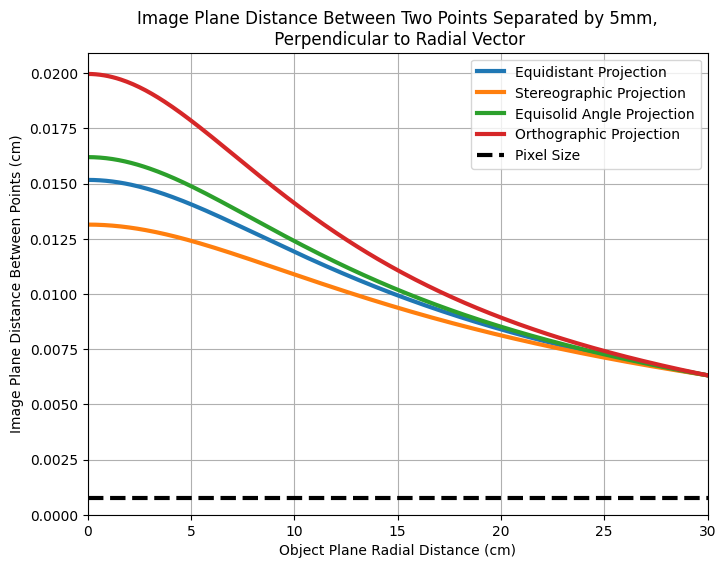

In [13]:
# Okay, now back to the original Cartesian grid. I want to understand how far apart two points in the object plane will be in the image plane. 
# There are two test cases: points that are separated by a distance perpendicular to a radial vector, and points that are separated along a radial vector

# Start with the first case. Look at the image plane distance as a function of the object plane radial distance for a fixed separation perpendicular to the radial vector. 
object_separation_cm = 0.5 # cm
object_plane_R = np.linspace(0., field_of_view_radius_cm, 300)

point_1_X = object_plane_R * np.cos(0) - object_separation_cm / 2 * np.sin(0)
point_1_Y = object_plane_R * np.sin(0) + object_separation_cm / 2 * np.cos(0)
point_2_X = object_plane_R * np.cos(0) + object_separation_cm / 2 * np.sin(0)
point_2_Y = object_plane_R * np.sin(0) - object_separation_cm / 2 * np.cos(0)

point_1_theta = np.arctan(np.sqrt(point_1_X**2 + point_1_Y**2) / distance_to_image_cm)
point_1_phi = np.arctan2(point_1_Y, point_1_X)
point_2_theta = np.arctan(np.sqrt(point_2_X**2 + point_2_Y**2) / distance_to_image_cm)
point_2_phi = np.arctan2(point_2_Y, point_2_X)

# plt.plot(point_1_X, point_1_Y, label='Point 1')
# plt.plot(point_2_X, point_2_Y, label='Point 2')
# plt.xlim(-field_of_view_radius_cm, field_of_view_radius_cm)
# plt.ylim(-field_of_view_radius_cm, field_of_view_radius_cm)
# plt.xlabel('Object Plane X (cm)')
# plt.ylabel('Object Plane Y (cm)')


# Now calculate hof far apart the two points are in the image plane for each projection.
# For the equidistant projection:
point_1_image_X_equidistant = focal_length_requirement_equidistant * point_1_theta * np.cos(point_1_phi)
point_1_image_Y_equidistant = focal_length_requirement_equidistant * point_1_theta * np.sin(point_1_phi)
point_2_image_X_equidistant = focal_length_requirement_equidistant * point_2_theta * np.cos(point_2_phi)
point_2_image_Y_equidistant = focal_length_requirement_equidistant * point_2_theta * np.sin(point_2_phi)
image_distance_equidistant = np.sqrt((point_2_image_X_equidistant - point_1_image_X_equidistant)**2 + (point_2_image_Y_equidistant - point_1_image_Y_equidistant)**2)
# For the stereographic projection:
point_1_image_X_stereographic = 2 * focal_length_requirement_stereographic * np.tan(point_1_theta/2) * np.cos(point_1_phi)
point_1_image_Y_stereographic = 2 * focal_length_requirement_stereographic * np.tan(point_1_theta/2) * np.sin(point_1_phi)
point_2_image_X_stereographic = 2 * focal_length_requirement_stereographic * np.tan(point_2_theta/2) * np.cos(point_2_phi)
point_2_image_Y_stereographic = 2 * focal_length_requirement_stereographic * np.tan(point_2_theta/2) * np.sin(point_2_phi)
image_distance_stereographic = np.sqrt((point_2_image_X_stereographic - point_1_image_X_stereographic)**2 + (point_2_image_Y_stereographic - point_1_image_Y_stereographic)**2)
# For the equisolid angle projection:
point_1_image_X_equisolid = 2 * focal_length_requirement_equisolid * np.sin(point_1_theta/2) * np.cos(point_1_phi)
point_1_image_Y_equisolid = 2 * focal_length_requirement_equisolid * np.sin(point_1_theta/2) * np.sin(point_1_phi)
point_2_image_X_equisolid = 2 * focal_length_requirement_equisolid * np.sin(point_2_theta/2) * np.cos(point_2_phi)
point_2_image_Y_equisolid = 2 * focal_length_requirement_equisolid * np.sin(point_2_theta/2) * np.sin(point_2_phi)
image_distance_equisolid = np.sqrt((point_2_image_X_equisolid - point_1_image_X_equisolid)**2 + (point_2_image_Y_equisolid - point_1_image_Y_equisolid)**2)
# For the orthographic projection:

point_1_image_X_orthographic = focal_length_requirement_orthographic * np.sin(point_1_theta) * np.cos(point_1_phi)
point_1_image_Y_orthographic = focal_length_requirement_orthographic * np.sin(point_1_theta) * np.sin(point_1_phi)
point_2_image_X_orthographic = focal_length_requirement_orthographic * np.sin(point_2_theta) * np.cos(point_2_phi)
point_2_image_Y_orthographic = focal_length_requirement_orthographic * np.sin(point_2_theta) * np.sin(point_2_phi)
image_distance_orthographic = np.sqrt((point_2_image_X_orthographic - point_1_image_X_orthographic)**2 + (point_2_image_Y_orthographic - point_1_image_Y_orthographic)**2)
# Now we can plot the image distance as a function of the object plane radial distance for each projection.
plt.figure(figsize=(8, 6)) 
plt.plot(object_plane_R, image_distance_equidistant, label='Equidistant Projection', linewidth=3)
plt.plot(object_plane_R, image_distance_stereographic, label='Stereographic Projection', linewidth=3)    
plt.plot(object_plane_R, image_distance_equisolid, label='Equisolid Angle Projection', linewidth=3)
plt.plot(object_plane_R, image_distance_orthographic, label='Orthographic Projection', linewidth=3)

# Also plot flat line at pixel size to see where the points become indistinguishable.
plt.axhline(pixel_size_cm, color='k', linestyle='--', label='Pixel Size', linewidth=3)


plt.xlabel('Object Plane Radial Distance (cm)')
plt.ylabel('Image Plane Distance Between Points (cm)')
plt.title('Image Plane Distance Between Two Points Separated by 5mm,\n Perpendicular to Radial Vector')
plt.legend()
plt.xlim(0, field_of_view_radius_cm)
plt.ylim(0, None)
plt.grid()










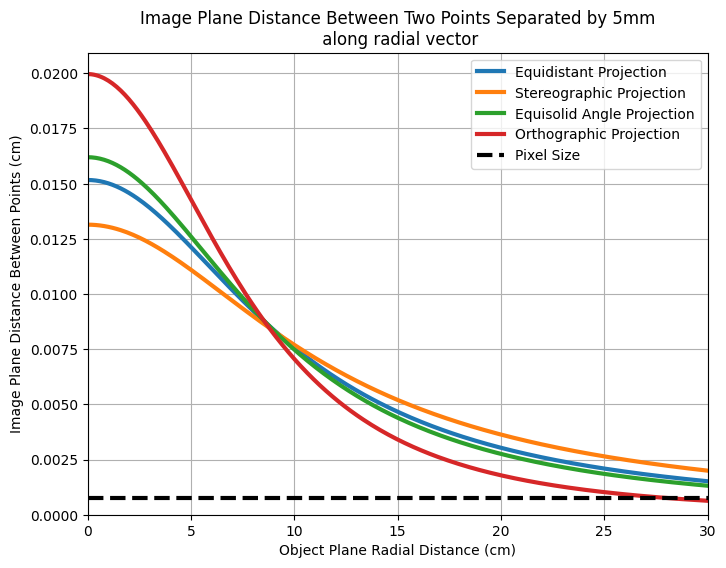

In [14]:
# Now we'll look at the second case, where the points are separated along the radial vector.

object_separation_cm = 0.5 # cm
object_plane_R = np.linspace(0., field_of_view_radius_cm, 300)

point_1_X = (object_plane_R - object_separation_cm / 2) * np.cos(0)
point_1_Y = (object_plane_R - object_separation_cm / 2) * np.sin(0)
point_2_X = (object_plane_R + object_separation_cm / 2) * np.cos(0)
point_2_Y = (object_plane_R + object_separation_cm / 2) * np.sin(0)

point_1_theta = np.arctan(np.sqrt(point_1_X**2 + point_1_Y**2) / distance_to_image_cm)
point_1_phi = np.arctan2(point_1_Y, point_1_X)
point_2_theta = np.arctan(np.sqrt(point_2_X**2 + point_2_Y**2) / distance_to_image_cm)
point_2_phi = np.arctan2(point_2_Y, point_2_X)


# Now calculate hof far apart the two points are in the image plane for each projection.
# For the equidistant projection:
point_1_image_X_equidistant = focal_length_requirement_equidistant * point_1_theta * np.cos(point_1_phi)
point_1_image_Y_equidistant = focal_length_requirement_equidistant * point_1_theta * np.sin(point_1_phi)
point_2_image_X_equidistant = focal_length_requirement_equidistant * point_2_theta * np.cos(point_2_phi)
point_2_image_Y_equidistant = focal_length_requirement_equidistant * point_2_theta * np.sin(point_2_phi)
image_distance_equidistant = np.sqrt((point_2_image_X_equidistant - point_1_image_X_equidistant)**2 + (point_2_image_Y_equidistant - point_1_image_Y_equidistant)**2)
# For the stereographic projection:
point_1_image_X_stereographic = 2 * focal_length_requirement_stereographic * np.tan(point_1_theta/2) * np.cos(point_1_phi)
point_1_image_Y_stereographic = 2 * focal_length_requirement_stereographic * np.tan(point_1_theta/2) * np.sin(point_1_phi)
point_2_image_X_stereographic = 2 * focal_length_requirement_stereographic * np.tan(point_2_theta/2) * np.cos(point_2_phi)
point_2_image_Y_stereographic = 2 * focal_length_requirement_stereographic * np.tan(point_2_theta/2) * np.sin(point_2_phi)
image_distance_stereographic = np.sqrt((point_2_image_X_stereographic - point_1_image_X_stereographic)**2 + (point_2_image_Y_stereographic - point_1_image_Y_stereographic)**2)
# For the equisolid angle projection:
point_1_image_X_equisolid = 2 * focal_length_requirement_equisolid * np.sin(point_1_theta/2) * np.cos(point_1_phi)
point_1_image_Y_equisolid = 2 * focal_length_requirement_equisolid * np.sin(point_1_theta/2) * np.sin(point_1_phi)
point_2_image_X_equisolid = 2 * focal_length_requirement_equisolid * np.sin(point_2_theta/2) * np.cos(point_2_phi)
point_2_image_Y_equisolid = 2 * focal_length_requirement_equisolid * np.sin(point_2_theta/2) * np.sin(point_2_phi)
image_distance_equisolid = np.sqrt((point_2_image_X_equisolid - point_1_image_X_equisolid)**2 + (point_2_image_Y_equisolid - point_1_image_Y_equisolid)**2)
# For the orthographic projection:

point_1_image_X_orthographic = focal_length_requirement_orthographic * np.sin(point_1_theta) * np.cos(point_1_phi)
point_1_image_Y_orthographic = focal_length_requirement_orthographic * np.sin(point_1_theta) * np.sin(point_1_phi)
point_2_image_X_orthographic = focal_length_requirement_orthographic * np.sin(point_2_theta) * np.cos(point_2_phi)
point_2_image_Y_orthographic = focal_length_requirement_orthographic * np.sin(point_2_theta) * np.sin(point_2_phi)
image_distance_orthographic = np.sqrt((point_2_image_X_orthographic - point_1_image_X_orthographic)**2 + (point_2_image_Y_orthographic - point_1_image_Y_orthographic)**2)
# Now we can plot the image distance as a function of the object plane radial distance for each projection.
plt.figure(figsize=(8, 6)) 
plt.plot(object_plane_R, image_distance_equidistant, label='Equidistant Projection', linewidth=3)
plt.plot(object_plane_R, image_distance_stereographic, label='Stereographic Projection', linewidth=3)    
plt.plot(object_plane_R, image_distance_equisolid, label='Equisolid Angle Projection', linewidth=3)
plt.plot(object_plane_R, image_distance_orthographic, label='Orthographic Projection', linewidth=3)

# Also plot flat line at pixel size to see where the points become indistinguishable.
plt.axhline(pixel_size_cm, color='k', linestyle='--', label='Pixel Size', linewidth=3)


plt.xlabel('Object Plane Radial Distance (cm)')
plt.ylabel('Image Plane Distance Between Points (cm)')
plt.title('Image Plane Distance Between Two Points Separated by 5mm\n along radial vector')
plt.legend()
plt.xlim(0, field_of_view_radius_cm)
plt.ylim(0, None)
plt.grid()










In [ ]:
# Okay, now let's assume the light scene I'm trying to image consists of two straight lines perpenducular to the object plane, going into the page. Each is 5mm long, and they are separated by 5mm distance.
# I want to know what this will look like on my sensor.



